# Assignment of LS - Least Squares

### Install required packages from requirements.txt (as per interactive lecture)

In [4]:
# Uncomment the line below to install required packages if something is missing
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Necessary imports
try:
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import plotly.graph_objects as go
    import matplotlib.pyplot as plt
    import plotly.express as px
    from plotly.subplots import make_subplots
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed
    from scipy.optimize import minimize, curve_fit
    from scipy import linalg
    import warnings
    warnings.filterwarnings('ignore')
    
    # Set random seed for reproducibility
    np.random.seed(42)
    
    print("🎉 All imports successful! You're ready to start solving problems!")
    
except ImportError as e:
    print(f"❌ Import Error: {e}")
    print("📋 Solution: Run the package verification cell above to check your setup")
    print("💡 Or try: pip install numpy pandas plotly ipywidgets scipy")

🎉 All imports successful! You're ready to start solving problems!


### Question 1 - Linear Model Setup and Normal Equations

A renewable energy company is testing solar panel efficiency. They collected power output data
at different irradiance levels.
Assume the model:
$$y = \theta_0 + \theta_1 x + \varepsilon$$

a) Setup the matrix X, and response vector y for this problem.
    - From the table of irradiance x, we have 5 observations + from the model we have 2 parameters. Where the response vector should be m x 1, design matrix m x n = 5 x 2.

In [23]:
# Setup of the matrix
x = np.array([100,200,300,400,500], dtype=float) # the irridiance in W/m^2
y = np.array([18.2,36.8,54.1,73.5,91.2], dtype=float) # the power output in W

# design matrix for y = theta0 + theta1*x + epsilon
m = x.size 
X = np.column_stack([np.ones(m), x]) # to acheive the correct design matrix

# establish the parameter vector, which are yet to predictet
theta = np.zeros((2,1))

# debug/check that things are setup correctly
print("="*30)
print(f"Observations, m: {m}")
print(f"Shape X:{X.shape}")
print(f"Shape y: {y.shape}")
print(f"Shape theta, theta: {theta.shape}")
print("="*30)
# solution to a)
print(f"\nX =\n {X}")
print(f"\ny =\n {y}")
print(f"\ntheta =\n {theta}")
print("="*30)


Observations, m: 5
Shape X:(5, 2)
Shape y: (5,)
Shape theta, theta: (2, 1)

X =
 [[  1. 100.]
 [  1. 200.]
 [  1. 300.]
 [  1. 400.]
 [  1. 500.]]

y =
 [18.2 36.8 54.1 73.5 91.2]

theta =
 [[0.]
 [0.]]


In [24]:
# Solved b) by hand in submitted .pdf document
# This cell to verify my calculation.

print(f"X^T * X =\n {X.T @ X}\n")
print("="*30)
print(f"\nX^T * y =\n {X.T @ y}\n")



X^T * X =
 [[5.0e+00 1.5e+03]
 [1.5e+03 5.5e+05]]


X^T * y =
 [   273.8 100410. ]



In [25]:
# c) solve the normal equations to find theta^and iterpret the physical meaning of both

# from the theory we know that as long as we suppose that the columns of X are linearly independent, which they are (x), we can solve theta^ = (X.T @ X)^-1 * X.T*y

theta_hat = np.linalg.inv(X.T @ X) @ (X.T @ y)

print(f"Theta hat shape: {theta_hat.shape}\n")
print(f"Theta hat =\n {theta_hat}\n")

# then we can retreive parameteres theta0 and theta1
theta_0 = theta_hat[0]
theta_1 = theta_hat[1]
print(f"Value of theta0 = {theta_0:.2f}\nValue of theta1 = {theta_1:.2f}\n")

# further we can now calculate the residuals (epsilon):
y_hat = theta_0 + (theta_1*x)
residuals = y_hat - y
y_line = y_hat + residuals
print(f"The predictet y points: {y_hat}\nThe residuals: {residuals}")

Theta hat shape: (2,)

Theta hat =
 [-0.05    0.1827]

Value of theta0 = -0.05
Value of theta1 = 0.18

The predictet y points: [18.22 36.49 54.76 73.03 91.3 ]
The residuals: [ 0.02 -0.31  0.66 -0.47  0.1 ]


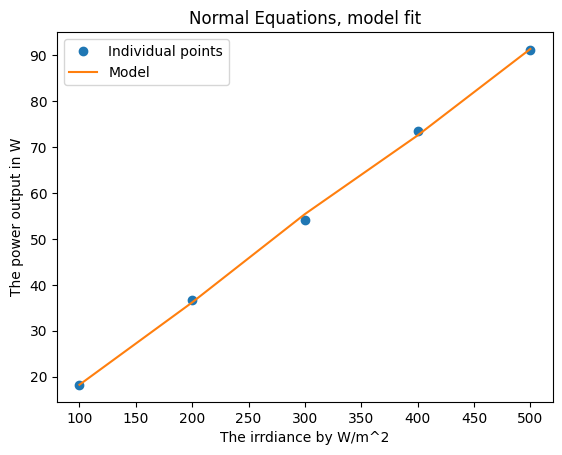

In [9]:
# then we can use this to plot, such that we can comment on the model fit:
plt.plot(x, y, 'o', label="Individual points")
plt.plot(x, y_line, label="Model")

plt.xlabel("The irrdiance by W/m^2")
plt.ylabel("The power output in W")
plt.title("Normal Equations, model fit")
plt.legend()

plt.show()

In [26]:
# MSE evaluting
def calculate_mse(y_true, y_pred):
    return np.mean((y_true-y_pred)**2)

print(f"MSE = {calculate_mse(y, y_hat):.2f}")

MSE = 0.15


Based upon the plotted line, residuals and MSE the model fit is quality is high, so it is a good prediction of the power output between and over the already

### Question 2 - Feature Engineering and Polynomial Models

A materials engineer is studying the stress-strain relationship for a new polymer. The data
suggests a quadratic relationship (table in document).

The engineer wants to fit:
$$y = \theta_0 + \theta_1 x + \theta_2x^2 + \varepsilon$$

In [27]:
# a) Construct the appropriate design matrix for this polynomial model.
x = np.array([
    0.5,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0
    ], dtype=float)

y = np.array([
    12.1,
    22.8,
    31.2,
    37.5,
    41.8,
    44.2], dtype=float)

# design matrix for y = theta0 + theta1*x + theta2*x^2 + epsilon
m = x.size 
X = np.column_stack([np.ones(m), x, x**2]) # to acheive the correct design matrix (now 3x3)

print(f"The matrix:\n {X}\nShape: {X.shape}\ny: {y}\nShape: {y.shape}")


The matrix:
 [[1.   0.5  0.25]
 [1.   1.   1.  ]
 [1.   1.5  2.25]
 [1.   2.   4.  ]
 [1.   2.5  6.25]
 [1.   3.   9.  ]]
Shape: (6, 3)
y: [12.1 22.8 31.2 37.5 41.8 44.2]
Shape: (6,)


b) Explain why this is still cinsidered a linear model, despite the polynomial term (x^2).
- A model is considered linear if it is linear in the parameters, which means that the parameters
appear linearly in the equation. In this case, even though the model includes a polynomial term of x squared (x^2),
the parameters theta_0, theta_1 and theta_2 appear linearly. Therefore, it is still classified as a linear model. 

In [28]:
# c) Set up the normal equations and solve for the parameters estimate.

# normal equations model
theta_hat_poly = np.linalg.inv(X.T @ X) @ (X.T @ y)
theta_0_poly, theta_1_poly, theta_2_poly = theta_hat_poly[0], theta_hat_poly[1], theta_hat_poly[2]
print(f"Theta0 polynomial: {theta_0_poly:.2f}, Theta1 polynomial: {theta_1_poly:.2f}, Theta2 polynomial: {theta_2_poly:.2f}")

# also setting up the correct model for plotting later:
y_hat_poly = theta_0_poly + (theta_1_poly*x) + (theta_2_poly*(x**2))
residuals_poly = y_hat_poly - y
y_line_poly = y_hat_poly + residuals_poly
# checking the residuals
for i in range(len(x)):
    print(f"The {i} polynomial residual: {residuals_poly[i]:.4f}")

Theta0 polynomial: -0.43, Theta1 polynomial: 27.26, Theta2 polynomial: -4.14
The 0 polynomial residual: 0.0679
The 1 polynomial residual: -0.1021
The 2 polynomial residual: -0.0400
The 3 polynomial residual: 0.0543
The 4 polynomial residual: 0.0807
The 5 polynomial residual: -0.0607


In [29]:
# d) Compare the quadratic fit to a simple linear model. Which is better and why?

# need to set it up for linear:
X_linear = np.column_stack([np.ones(m), x])
theta_hat_linear = np.linalg.inv(X_linear.T @ X_linear) @ (X_linear.T @ y)
theta_0_lin, theta_1_lin = theta_hat_linear[0], theta_hat_linear[1]
# debug
print(f"Theta0 linear: {theta_0_lin:.2f}, Theta1 linear: {theta_1_lin:.2f}")
y_hat_lin = theta_0_lin + (theta_1_lin*x)
residuals_lin = y_hat_lin - y
y_line_lin = y_hat_lin + residuals_lin
# printting the residuals
for i in range(len(x)):
    print(f"The {i} linear residual: {residuals_lin[i]:.4f}")
    

Theta0 linear: 9.22, Theta1 linear: 12.79
The 0 linear residual: 3.5143
The 1 linear residual: -0.7914
The 2 linear residual: -2.7971
The 3 linear residual: -2.7029
The 4 linear residual: -0.6086
The 5 linear residual: 3.3857


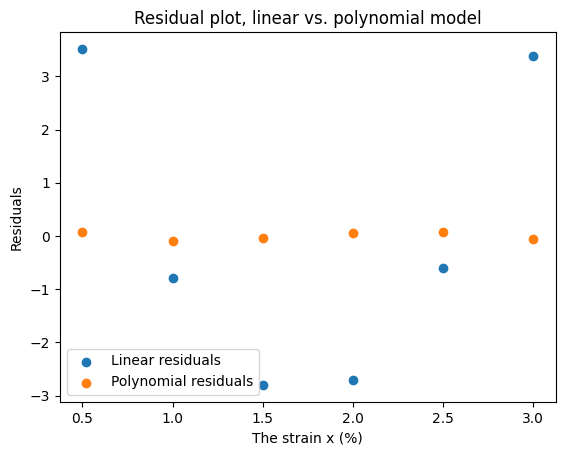

In [30]:
# plotting the residuals for better visual representation
plt.scatter(x, residuals_lin, label="Linear residuals")
plt.scatter(x, residuals_poly, label="Polynomial residuals")

plt.xlabel("The strain x (%)")
plt.ylabel("Residuals")
plt.title("Residual plot, linear vs. polynomial model")
plt.legend()

plt.show()

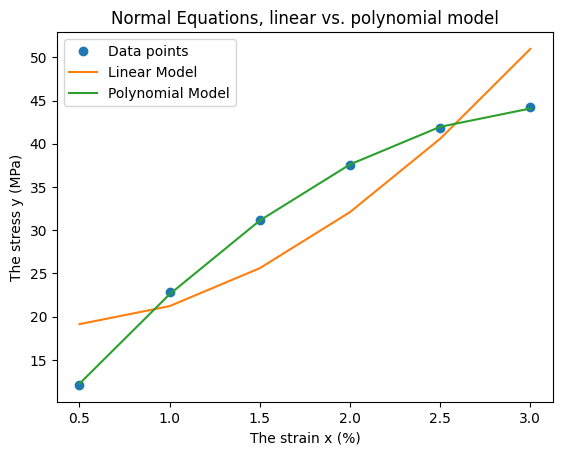

Polynomial model => "best" fit


In [31]:
# now we can plot, to comment on which model is better.
plt.plot(x, y, 'o', label="Data points")

plt.plot(x, y_line_lin, label="Linear Model")
plt.plot(x, y_line_poly, label="Polynomial Model")


plt.xlabel("The strain x (%)")
plt.ylabel("The stress y (MPa)")
plt.title("Normal Equations, linear vs. polynomial model")
plt.legend()

plt.show()

# MSE score, for fun
print("Polynomial model => \"best\" fit" if calculate_mse(y, y_hat_lin) > calculate_mse(y, y_hat_poly) else "Linear model => \"best\" fit")

As we can see from the plot above, the polynomial model is a much better fit compared to the linear model as they align more close with the data points. The reason for this being that the data suggests a quadratic relationship, which the polynomial model can capture effectively, while the linear model is quite off from the data points. Which the MSE also confirms in the code.

### Question 3 - Gradient Descent Implementation
Consider the simple least squares problem with cost function (from task):
$$J(\theta_0, \theta_1) = \frac{1}{2m}\sum_{i=1}^{m}(y_i - \theta_0-\theta_1x_i)^2$$
for the dataset: (x_i, y_i) = {(1, 3), (2, 5), (3, 7), (4, 9)}.

a) Derive the partial derivatives of J with respect to theta_0 and theta_1 => done by hand in submitted .pdf document.

b) Write the batch gradient descent update equations for theta_0 and theta_1. => done by hand in submitted .pdf document.

In [36]:
# c) implementation of GD in with alpha = 0.01 and initial guess theta0 = 0 and theta1 = 0. Run for 1000 iterations

#defining the variables & functions, since we are going to iterate:
x_gd = np.array([1,2,3,4])
y_gd = np.array([3,5,7,9])
m = len(x_gd)

#help function, cost function:
def cost_func(theta0, theta1, x, y):
    predictions = theta0 + theta1 * x
    m = len(y)
    
    cost = (1/(2*m)) * np.sum((y-predictions)**2)
    
    return cost

# Main GD function
def gradient_descent(x, y, alpha, iterations):
    # setup varibales based on task
    m = len(y)
    theta0, theta1 = 0.0 , 0.0
    hist_theta0, hist_theta1 = [theta0], [theta1]
    history_of_cost = []
    
    for _ in range(iterations):
        # the gradient predictions & error
        predictions = theta0 + theta1 * x
        error = predictions - y
        
        # the partial derivation of gradients respect to theta0 and theta1
        theta0_gradient = (1/m) * np.sum(error)
        theta1_gradient = (1/m) * np.sum(error * x)
        
        # updating the gradient
        theta0 = theta0 - alpha * theta0_gradient
        theta1 = theta1 - alpha * theta1_gradient
        
        # memorize history
        history_of_cost.append(cost_func(theta0, theta1, x, y))
        hist_theta0.append(theta0)
        hist_theta1.append(theta1)
        
    
    # iterations done, return
    return theta0, theta1, history_of_cost, hist_theta0, hist_theta1
        
        

In [37]:
# Set the initial variables
iterations = 1000
alpha = 0.01
# run the gradient descent.
gd_theta0, gd_theta1, hist_of_cost, hist_a0, hist_a1 = gradient_descent(x_gd, y_gd, alpha, iterations)

print(f"""
      Final theta0 = {gd_theta0:.6f}
      Final theta1 = {gd_theta1:.6f}
      Final Cost = {hist_of_cost[-1]:.14f}
      """)


      Final theta0 = 0.935927
      Final theta1 = 2.021793
      Final Cost = 0.00034281910321
      


In [38]:
# Part d & e: Analysis and comparison
# Analytical solution
X_GD = np.column_stack([np.ones(m), x_gd])
analytical_theta = np.linalg.solve(X_GD.T @ X_GD, X_GD.T @ y_gd) 

print(f"""
      GD => theta0: {gd_theta0:.6f} | theta1: {gd_theta1:.6f}
      AN => theta0: {analytical_theta[0]:.6f} | theta1: {analytical_theta[1]:.6f}
      
      Difference: Theta0: {abs(analytical_theta[0]-gd_theta0):.2e} | Theta1: {abs(analytical_theta[1]-gd_theta1):.2e}
      """)



      GD => theta0: 0.935927 | theta1: 2.021793
      AN => theta0: 1.000000 | theta1: 2.000000

      Difference: Theta0: 6.41e-02 | Theta1: 2.18e-02
      


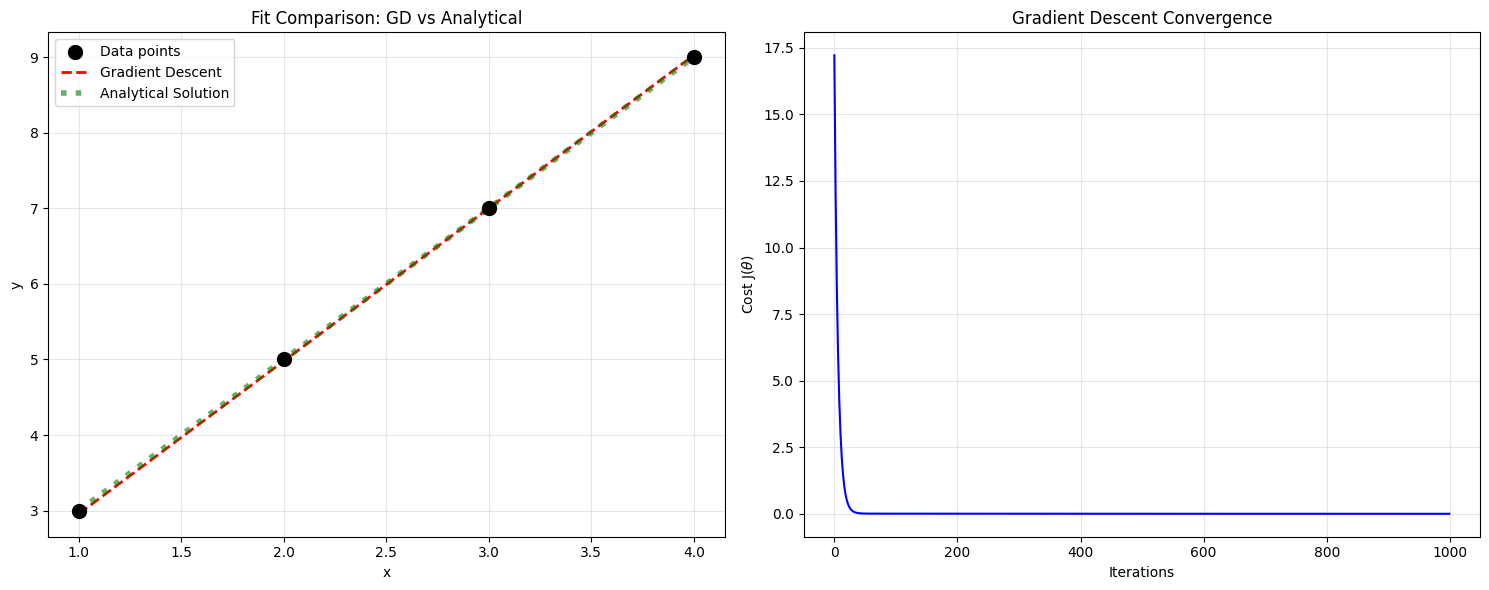

In [39]:
# Generate points for plotting the regression lines smoothly
x_line = np.linspace(x_gd.min(), x_gd.max(), 100)

# Calculate the regression lines based on the calculated parameters
y_line_gd = gd_theta0 + gd_theta1 * x_line
y_line_analytical = analytical_theta[0] + analytical_theta[1] * x_line

# Create subplots: one for the fit comparison, one for the cost history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Visualizing the Solutions
ax1.scatter(x_gd, y_gd, color='black', label='Data points', s=100, zorder=3)
ax1.plot(x_line, y_line_gd, 'r--', label='Gradient Descent', linewidth=2)
# Using a thicker, semi-transparent line for analytical to see if they overlap
ax1.plot(x_line, y_line_analytical, 'g:', label='Analytical Solution', linewidth=4, alpha=0.6)

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Fit Comparison: GD vs Analytical')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Visualizing the Convergence (Cost History)
ax2.plot(hist_of_cost, color='blue')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Cost J($\\theta$)')
ax2.set_title('Gradient Descent Convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Question 4 - Brute Force Optimization

For the cost function:

$$J(\theta_1, \theta_2) = (\theta_1 - 2)^2 + 10(\theta_2 - \theta_1^2)^2$$

a) Implement a brute-force grid search over the ranges theta1 : [-2,4] & theta2 : [-1,5] with step size 0.1

In [43]:
# Implemtation of brute-force grid search
def brute_force_grid_search(func, theta1_range, theta2_range, step_size):
    theta1_values = np.arange(theta1_range[0], theta1_range[1] + step_size, step_size)
    theta2_values = np.arange(theta2_range[0], theta2_range[1] + step_size, step_size)
    
    min_cost = float('inf')
    best_theta1 = None
    best_theta2 = None
    
    for theta1 in theta1_values:
        for theta2 in theta2_values:
            cost = func(theta1, theta2)
            if cost < min_cost:
                min_cost = cost
                best_theta1 = theta1
                best_theta2 = theta2
                
    return best_theta1, best_theta2, min_cost

# testing the function
# defining the cost function
def rosenbrock_cost(theta1, theta2):
    return (theta1 - 2)**2 + 10 * (theta2 - theta1**2)**2
# defining the ranges and step size
theta1_range = [-2, 4]
theta2_range = [-1, 5]
step_size = 0.1
# running the brute-force grid search
best_theta1, best_theta2, min_cost = brute_force_grid_search(rosenbrock_cost, theta1_range, theta2_range, step_size)

# printing the results
print(f"Brute-Force Grid Search Results:")
print(f"Best theta1: {best_theta1:.2f}")
print(f"Best theta2: {best_theta2:.2f}")
print(f"Minimum Cost: {min_cost:.6f}")  

Brute-Force Grid Search Results:
Best theta1: 2.00
Best theta2: 4.00
Minimum Cost: 0.000000


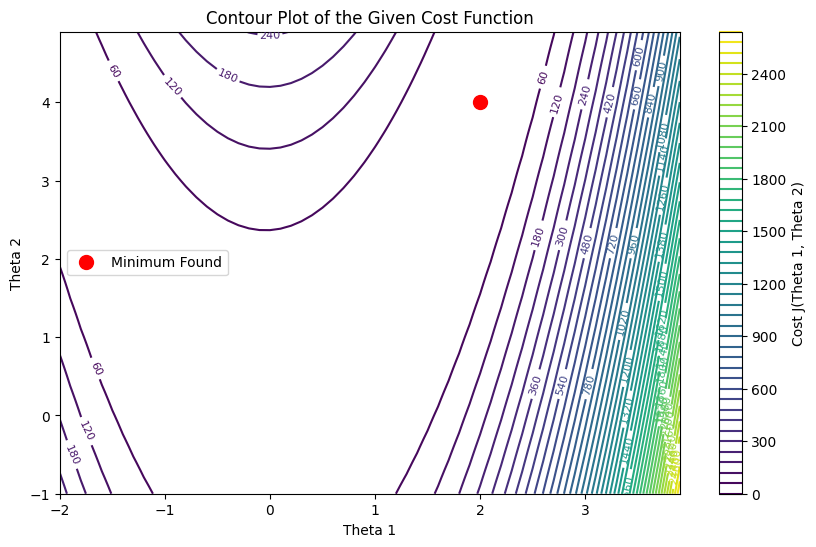

In [45]:
# b) create a contour plot of the cost function and mark the minimum found by the grid search
# Create a grid of theta1 and theta2 values
theta1_vals = np.arange(theta1_range[0], theta1_range[1], step_size)
theta2_vals = np.arange(theta2_range[0], theta2_range[1], step_size)
Theta1, Theta2 = np.meshgrid(theta1_vals, theta2_vals)

# show the cost function values on the grid
Cost_values = rosenbrock_cost(Theta1, Theta2)  
# Create the contour plot
plt.figure(figsize=(10, 6))
contour = plt.contour(Theta1, Theta2, Cost_values, levels=50, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.colorbar(label='Cost J(Theta 1, Theta 2)')
# Mark the minimum found by the grid search
plt.plot(best_theta1, best_theta2, 'ro', markersize=10, label='Minimum Found')
plt.xlabel('Theta 1')
plt.ylabel('Theta 2')
plt.title('Contour Plot of the Given Cost Function')
plt.legend()
plt.show()

In [ ]:
# c) compare the computiational cost of the brute-force grid search with that of gradient descent for finding the minimum of the same function
import time

# Timing the brute-force grid search
start_time_brute = time.time()
best_theta1, best_theta2, min_cost = brute_force_grid_search(rosenbrock_cost, theta1_range, theta2_range, step_size)
end_time_brute = time.time()
brute_force_time = end_time_brute - start_time_brute

# Timing Gradient Descent
def rosenbrock_gradient_descent(alpha, iterations):
    theta1, theta2 = 0.0, 0.0
    for _ in range(iterations):
        # calculate gradients
        
        grad_theta1 = 2 * (theta1 - 2) - 40 * theta1 * (theta2 - theta1**2)
        grad_theta2 = 20 * (theta2 - theta1**2)
        
        # update parameters
        theta1 -= alpha * grad_theta1
        theta2 -= alpha * grad_theta2
    return theta1, theta2

start_time_gd = time.time()
gd_theta1, gd_theta2 = rosenbrock_gradient_descent(alpha=0.01, iterations=1000)
end_time_gd = time.time()
gd_time = end_time_gd - start_time_gd

# Print the results
print(f"Brute-Force Grid Search Time: {brute_force_time:.6f} seconds")
print(f"Gradient Descent Time: {gd_time:.6f} seconds")
print(f"Difference in Time: {abs(brute_force_time - gd_time):.6f} seconds")
print(f"Brute-Force found minimum at Theta1: {best_theta1:.2f}, Theta2: {best_theta2:.2f} with Cost: {min_cost:.6f}")
print(f"Gradient Descent found minimum at Theta1: {gd_theta1:.2f}, Theta2: {gd_theta2:.2f}")

Brute-Force Grid Search Time: 0.001918 seconds
Gradient Descent Time: 0.000333 seconds
Difference in Time: 0.001585 seconds
Brute-Force found minimum at Theta1: 2.00, Theta2: 4.00 with Cost: 0.000000
Gradient Descent found minimum at Theta1: 1.58, Theta2: 2.21


d) Discuss when brute froce might be preferable despite its computational cost.

- Brute force might be preferable in situations where the search space is small and specific,
allowing for a comprehensive exploration of all possible solutions. It is also useful when the problem
is complex or lacks a clear structure, making it difficult to apply more detailed optimization techniques. Additionally, brute force can be advantageous when the cost of evaluating the objective function is low, enabling a thorough search without significant computational burden.

### Question 5 - Non-linear Least Sqaures (BOD Model)

$$y = \theta_1(1 - e^{-\theta_2 x})$$

a) Explain why standard linear squares (normal equations) cannot be directly applied to this model.
- Standard linear squares (normal equations) cannot be directly applied to this model because the model is non-linear in its parameters. The presence of the exponential term e^(-theta_2 * x) makes the relationship between the parameters (theta_1 and theta_2) and the response variable (y) non-linear. As a result, the assumptions underlying linear least squares, which require a linear relationship between the parameters and the response variable, are not satisfied.

b) Implement parameter estimation using scipy.otpimize.minimize with initial guess theta1 = 25, and theta 2 = 0.5.

In [52]:
# implement parameter estimation using scipy.otpimize.minimize with initial guess theta1 = 25, and theta 2 = 0.5.
from scipy.optimize import minimize
#  the BOD model function
def bod_model(x, theta1, theta2):
    return theta1 * (1 - np.exp(-theta2 * x))

# the cost function to minimize
def bod_cost_function(params, x, y):
    theta1, theta2 = params
    predictions = bod_model(x, theta1, theta2)
    return np.sum((y - predictions) ** 2)

#  data points
x_data = np.array([1, 2, 3, 4, 5, 7], dtype=float)
y_data = np.array([10.6, 16.0, 18.8, 20.9, 22.2, 23.8], dtype=float)

# initial guess for theta1 and theta2
initial_guess = [25.0, 0.5]

# the optimization using scipy.optimize.minimize
result = minimize(bod_cost_function, initial_guess, args=(x_data, y_data))

# the estimated parameters
estimated_theta1, estimated_theta2 = result.x

print(f"Estimated parameters:")
print(f"Theta1: {estimated_theta1:.4f}")
print(f"Theta2: {estimated_theta2:.4f}")

Estimated parameters:
Theta1: 23.8393
Theta2: 0.5499


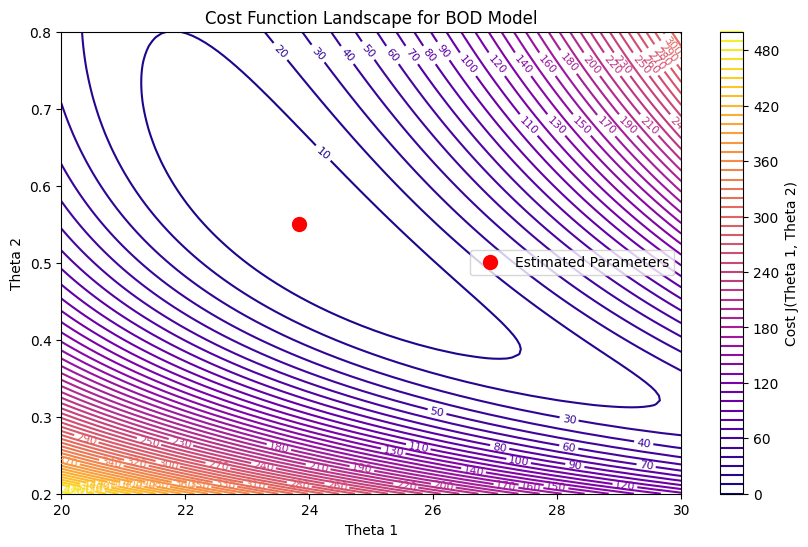

In [54]:
# c) Create a cost function landscape plot for theta1 in [20,30] and theta2 in [0.2,0.8] to visualize the optimization problem.

# Create a grid of theta1 and theta2 values

theta1_vals = np.linspace(20, 30, 100)
theta2_vals = np.linspace(0.2, 0.8, 100)
Theta1, Theta2 = np.meshgrid(theta1_vals, theta2_vals)

# Calculate the cost function values on the grid

Cost_values = np.zeros(Theta1.shape)
for i in range(Theta1.shape[0]):
    for j in range(Theta1.shape[1]):
        Cost_values[i, j] = bod_cost_function([Theta1[i, j], Theta2[i, j]], x_data, y_data)
        
# Create the contour plot

plt.figure(figsize=(10, 6))
contour = plt.contour(Theta1, Theta2, Cost_values, levels=50, cmap='plasma')
plt.clabel(contour, inline=True, fontsize=8)
plt.colorbar(label='Cost J(Theta 1, Theta 2)')

# Mark the estimated parameters found by optimization

plt.plot(estimated_theta1, estimated_theta2, 'ro', markersize=10, label='Estimated Parameters')

plt.xlabel('Theta 1')
plt.ylabel('Theta 2')
plt.title('Cost Function Landscape for BOD Model')
plt.legend()

plt.show()

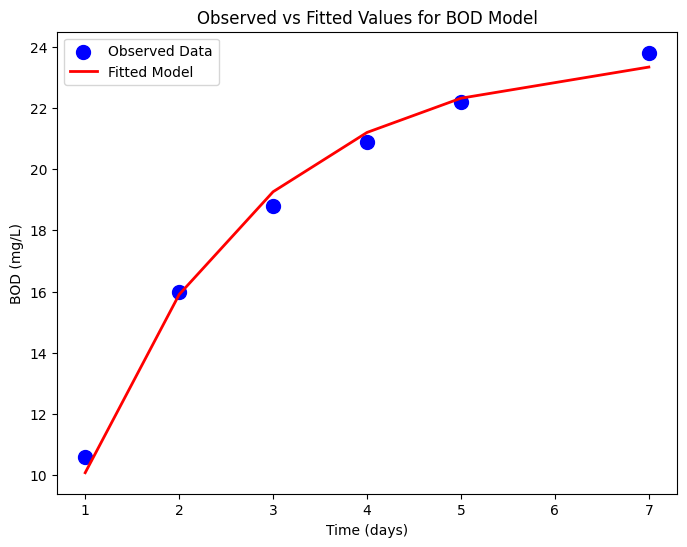

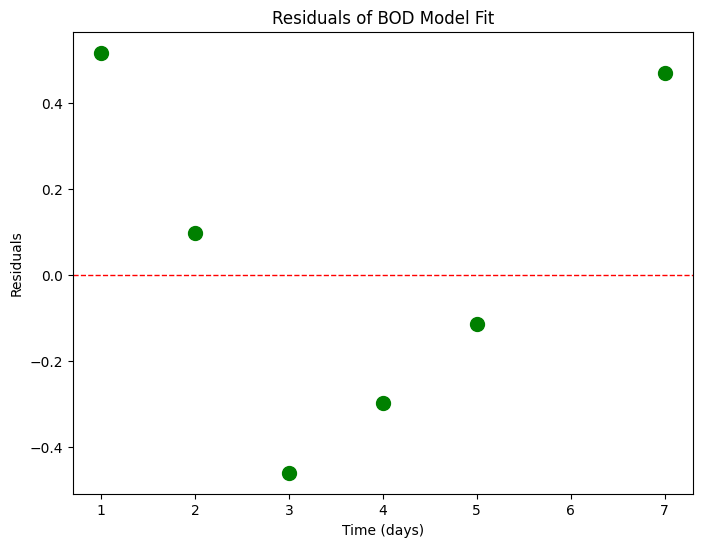

Mean Squared Error (MSE) of the fit: 0.1346


In [55]:
# d) Validate your fitted model by plotting prediced vs observed values and calculating residuals.

# predicted values using the estimated parameters and calulating residuals
y_predicted = bod_model(x_data, estimated_theta1, estimated_theta2)
residuals = y_data - y_predicted

# plot predicted vs observed values
plt.figure(figsize=(8, 6))

plt.scatter(x_data, y_data, color='blue', label='Observed Data', s=100)
plt.plot(x_data, y_predicted, color='red', label='Fitted Model', linewidth=2)

plt.xlabel('Time (days)')
plt.ylabel('BOD (mg/L)')

plt.title('Observed vs Fitted Values for BOD Model')
plt.legend()
plt.show()

# plot residuals
plt.figure(figsize=(8, 6))

plt.scatter(x_data, residuals, color='green', s=100)

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Time (days)')
plt.ylabel('Residuals')

plt.title('Residuals of BOD Model Fit')
plt.show()

# calculate and print MSE
mse = np.mean(residuals**2)
print(f"Mean Squared Error (MSE) of the fit: {mse:.4f}")

### Question 6 - Scaling Effects and Numerical Issues

In [57]:
# A process control engineer has temperatire data with very different scales
x_time = np.array([3600, 7200, 10800, 14400, 18000], dtype=float)  # time in seconds
y_temp = np.array([298.2, 423.7, 548.1, 671.8, 798.5], dtype=float)  # temperature in Kelvin

In [59]:
# a) fit the model y = theta0 + theta1x using both the original data and scaled data.
# Design matrix for original data
m = x_time.size
X_original = np.column_stack([np.ones(m), x_time])
# Normal equations solution for original data
theta_hat_original = np.linalg.inv(X_original.T @ X_original) @ (X_original.T @ y_temp)
theta0_original, theta1_original = theta_hat_original[0], theta_hat_original[1]
print(f"Original Data Fit: Theta0 = {theta0_original:.4f}, Theta1 = {theta1_original:.8f}")

# Scaling the data
x_time_scaled = (x_time - np.mean(x_time)) / np.std(x_time)
y_temp_scaled = (y_temp - np.mean(y_temp)) / np.std(y_temp)
# Design matrix for scaled data
X_scaled = np.column_stack([np.ones(m), x_time_scaled])
# Normal equations solution for scaled data
theta_hat_scaled = np.linalg.inv(X_scaled.T @ X_scaled) @ (X_scaled.T @ y_temp_scaled)
theta0_scaled, theta1_scaled = theta_hat_scaled[0], theta_hat_scaled[1]
print(f"Scaled Data Fit: Theta0 = {theta0_scaled:.4f}, Theta1 = {theta1_scaled:.4f}")

Original Data Fit: Theta0 = 173.4500, Theta1 = 0.03468611
Scaled Data Fit: Theta0 = -0.0000, Theta1 = 1.0000


In [68]:
# b) Implement gradient descent for both cases with the same learning rate. What happens and why?
def gradient_descent_scaled(x, y, alpha, iterations):
    m = len(y)
    theta0, theta1 = 0.0, 0.0
    for _ in range(iterations):
        predictions = theta0 + theta1 * x
        error = predictions - y
        theta0_gradient = (1/m) * np.sum(error)
        theta1_gradient = (1/m) * np.sum(error * x)
        theta0 -= alpha * theta0_gradient
        theta1 -= alpha * theta1_gradient
    return theta0, theta1

# Gradient descent parameters
iterations = 100000
alpha = 0.000000001
# Gradient descent on original data
gd_theta0_original, gd_theta1_original = gradient_descent_scaled(x_time, y_temp, alpha, iterations)
print(f"Gradient Descent Original Data: Theta0 = {gd_theta0_original:.4f}, Theta1 = {gd_theta1_original:.8f}")
# Gradient descent on scaled data
gd_theta0_scaled, gd_theta1_scaled = gradient_descent_scaled(x_time_scaled, y_temp_scaled, alpha, iterations)
print(f"Gradient Descent Scaled Data: Theta0 = {gd_theta0_scaled:.4f}, Theta1 = {gd_theta1_scaled:.4f}")

Gradient Descent Original Data: Theta0 = 0.0032, Theta1 = 0.04782602
Gradient Descent Scaled Data: Theta0 = -0.0000, Theta1 = 0.0001


In [ ]:
# What happens and why?
"""

Large x-values cause very large gradients for theta1, making gradient descent unstable
unless a very small learning rate is used. Feature scaling reduces gradient magnitudes,
allowing faster and more stable convergence without changing the optimal solution.

"""

# c) When feature scaling is critical, and when might it not be necessary?
"""

Feature scaling is critical when:

1. The features have vastly different scales, which can lead to inefficient convergence in optimization algorithms like gradient descent.

2. Regularization techniques are used, as they are sensitive to the scale of the features.

================

Feature scaling might not be necessary when:

1. The features are already on a similar scale, reducing the risk of convergence issues.

2. Using optimization algorithms that are less sensitive to feature scaling, such as tree-based methods (e.g., decision trees, random forests).

3. When interpretability of the model coefficients is a priority, as scaling can obscure the original meaning of the features.

"""

'\n\nFeature scaling is critical when:\n\n1. The features have vastly different scales, which can lead to inefficient convergence in optimization algorithms like gradient descent.\n\n2. Regularization techniques are used, as they are sensitive to the scale of the features.\n\n================\n\nFeature scaling might not be necessary when:\n\n1. The features are already on a similar scale, reducing the risk of convergence issues.\n\n2. Using optimization algorithms that are less sensitive to feature scaling, such as tree-based methods (e.g., decision trees, random forests).\n\n3. When interpretability of the model coefficients is a priority, as scaling can obscure the original meaning of the features.\n\n'

### Qustion 7 - WLS Application

A sensor network monitors air quality, but different sensors have different precisiion levels.
The data shows PM2.5 measurement withbassociated uncertainties.

In [70]:
x_hour = np.array([6,9,12,15,18,21], dtype=float)  # time at hour
y_pm25 = np.array([45.2,52.8,67.4,71.5,58.9,41.7], dtype=float)  # PM2.5 measurements
std_error = np.array([2.1,1.5,3.2,1.8,2.5,1.2], dtype=float)  # standard error

In [ ]:
# a) set up the WLS problem with weights w_i = 1 / std_error_i^2. Justify the choice.

# Design matrix for WLS
m = x_hour.size
X_wls = np.column_stack([np.ones(m), x_hour])

# Weights based on standard errors
weights = 1 / (std_error ** 2)
W = np.diag(weights)

print(f"Design Matrix X:\n{X_wls}\n")
print(f"Weights Matrix W:\n{W}\n")

# Justification:
"""
Weights are chosen as the inverse of the variance (std_error squared) to give more importance to observations with lower uncertainty. This approach minimizes the weighted sum of squared residuals, leading to more reliable parameter estimates when measurement errors vary across observations.
"""

Design Matrix X:
[[ 1.  6.]
 [ 1.  9.]
 [ 1. 12.]
 [ 1. 15.]
 [ 1. 18.]
 [ 1. 21.]]

Weights Matrix W:
[[0.22675737 0.         0.         0.         0.         0.        ]
 [0.         0.44444444 0.         0.         0.         0.        ]
 [0.         0.         0.09765625 0.         0.         0.        ]
 [0.         0.         0.         0.30864198 0.         0.        ]
 [0.         0.         0.         0.         0.16       0.        ]
 [0.         0.         0.         0.         0.         0.69444444]]



'\nWeights are chosen as the inverse of the variance (std_error squared) to give more importance to observations with lower uncertainty. This approach minimizes the weighted sum of squared residuals, leading to more reliable parameter estimates when measurement errors vary across observations.\n'

In [72]:
#b ) Derive and implement the weighted normal equations.
# Weighted normal equations solution
theta_hat_wls = np.linalg.inv(X_wls.T @ W @ X_wls) @ (X_wls.T @ W @ y_pm25)
theta0_wls, theta1_wls = theta_hat_wls[0], theta_hat_wls[1]
print(f"WLS Fit: Theta0 = {theta0_wls:.4f}, Theta1 = {theta1_wls:.4f}")

WLS Fit: Theta0 = 59.9199, Theta1 = -0.5245


In [73]:
# c) Compare the WLS with ordinary least squares (OLS). How do the parameter estimates differ and why?
# OLS solution for comparison
theta_hat_ols = np.linalg.inv(X_wls.T @ X_wls) @ (X_wls.T @ y_pm25)
theta0_ols, theta1_ols = theta_hat_ols[0], theta_hat_ols[1]
print(f"OLS Fit: Theta0 = {theta0_ols:.4f}, Theta1 = {theta1_ols:.4f}") 
# Comparison of WLS and OLS estimates
print(f"""
Comparison of WLS and OLS Estimates:
WLS => Theta0: {theta0_wls:.4f}, Theta1: {theta1_wls:.4f}
OLS => Theta0: {theta0_ols:.4f}, Theta1: {theta1_ols:.4f}
""")

OLS Fit: Theta0 = 55.6200, Theta1 = 0.0467

Comparison of WLS and OLS Estimates:
WLS => Theta0: 59.9199, Theta1: -0.5245
OLS => Theta0: 55.6200, Theta1: 0.0467



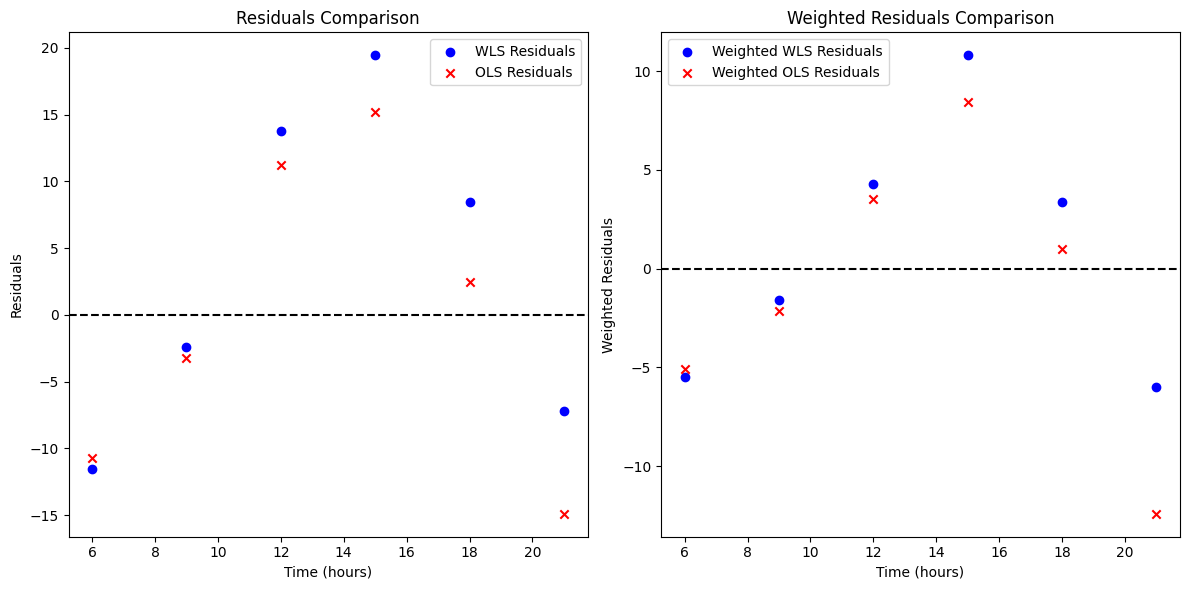

In [78]:
# d) Calculate and comare the weighted and unweighted residuals. Which approach gives a better representaion of measurement uncertainty?
# Calculate residuals
y_hat_wls = theta0_wls + theta1_wls * x_hour
residuals_wls = y_pm25 - y_hat_wls
y_hat_ols = theta0_ols + theta1_ols * x_hour
residuals_ols = y_pm25 - y_hat_ols

# Weighted residuals
weighted_residuals_wls = residuals_wls * np.sqrt(weights)
weighted_residuals_ols = residuals_ols * np.sqrt(weights)
    
# plotting residuals for visual comparison
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(x_hour, residuals_wls, color='blue', label='WLS Residuals')
plt.scatter(x_hour, residuals_ols, color='red', label='OLS Residuals', marker='x')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Time (hours)')
plt.ylabel('Residuals')
plt.title('Residuals Comparison')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(x_hour, weighted_residuals_wls, color='blue', label='Weighted WLS Residuals')
plt.scatter(x_hour, weighted_residuals_ols, color='red', label='Weighted OLS Residuals', marker='x')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Time (hours)')
plt.ylabel('Weighted Residuals')
plt.title('Weighted Residuals Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion:
# Since each measurement has a different standard deviation sigma_i, WLS with w_i = 1/sigma_i^2
# is the appropriate model: it minimizes sum_i (r_i / sigma_i)^2, i.e., residuals measured in
# “number of standard deviations”. Therefore WLS better reflects the stated measurement
# uncertainties than OLS, which implicitly assumes equal variance for all measurements.

### Question 8 - Comprehensive Python Implementation

Design a complete least squares analysis pipeline for a real engineering problem of your choice.

a) A SOC monitors authentication logs and wants a quick, explainable model to estimate how “risky” an authentication burst is, based only on a single measurable signal available in real time.

**Problem statement**:

For each 10-minute window on a production VPN gateway, measure:

- x = number of failed login attempts from the top offending source IP in that window

- y = analyst-assigned risk score for the window (0–100), based on triage (higher means more likely malicious and worth immediate action)

The data collected is as follows:

| Failed logins x (count / 10 min) | Risk score y (0-100) |
|----------------|----------------|
| 2 | 6 |
| 4 | 11 |
| 7 | 19 |
| 10 | 27 |
| 14 | 38 |
| 18 | 52 |
| 22 | 61 |
| 25 | 67 |
| 27 | 70 |
| 30 | 74 |





b) Implementation of at least three solution models: normal equations, gradient descent and scipy.optimize.minimize.

Normal Equations Fit: Theta0 = 1.8789, Theta1 = 2.5548


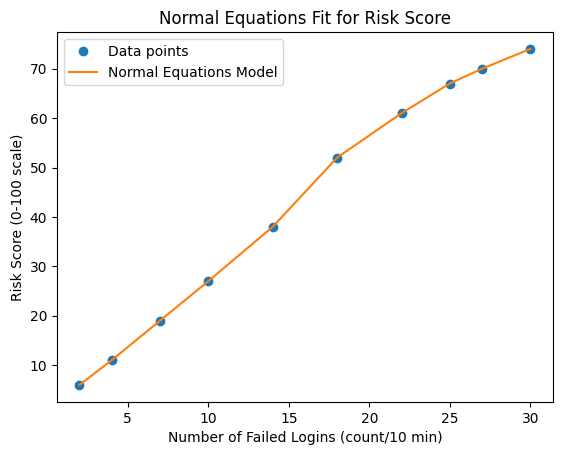

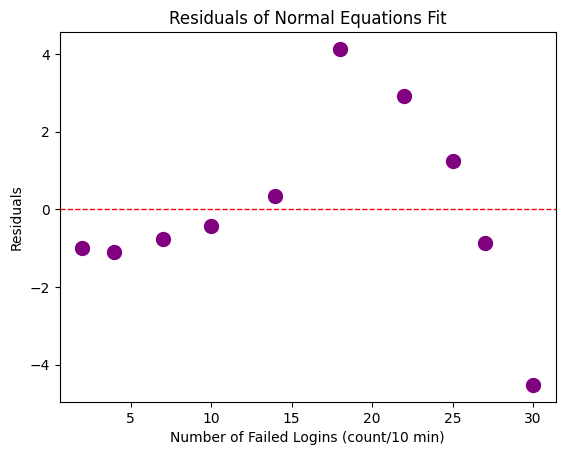

In [87]:
# Defining the variables:
x_failed_logins = np.array([2, 4, 7, 10, 14, 18, 22, 25, 27, 30],dtype=float)  # failed login attempts per 10 minutes(count / 10 min)
y_risk_score = np.array([6, 11, 19, 27, 38, 52, 61, 67, 70, 74],dtype=float)  # analyst risk score (0–100)

# first solution model, normal equations
m = x_failed_logins.size
X_risk = np.column_stack([np.ones(m), x_failed_logins])
theta_hat_risk = np.linalg.inv(X_risk.T @ X_risk) @ (X_risk.T @ y_risk_score)
theta0_risk, theta1_risk = theta_hat_risk[0], theta_hat_risk[1]
print(f"Normal Equations Fit: Theta0 = {theta0_risk:.4f}, Theta1 = {theta1_risk:.4f}")

# plotting the normal equations fit and residuals
y_hat_risk = theta0_risk + theta1_risk * x_failed_logins
residuals_risk = y_risk_score - y_hat_risk
y_line_risk = y_hat_risk + residuals_risk

plt.plot(x_failed_logins, y_risk_score, 'o', label="Data points")
plt.plot(x_failed_logins, y_line_risk, label="Normal Equations Model")
plt.xlabel("Number of Failed Logins (count/10 min)")
plt.ylabel("Risk Score (0-100 scale)")
plt.title("Normal Equations Fit for Risk Score")
plt.legend()
plt.show()

# residuals plot
plt.scatter(x_failed_logins, residuals_risk, color='purple', s=100)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Number of Failed Logins (count/10 min)')
plt.ylabel('Residuals')
plt.title('Residuals of Normal Equations Fit')
plt.show()

Gradient Descent Fit: Theta0 = 1.7507, Theta1 = 2.5607


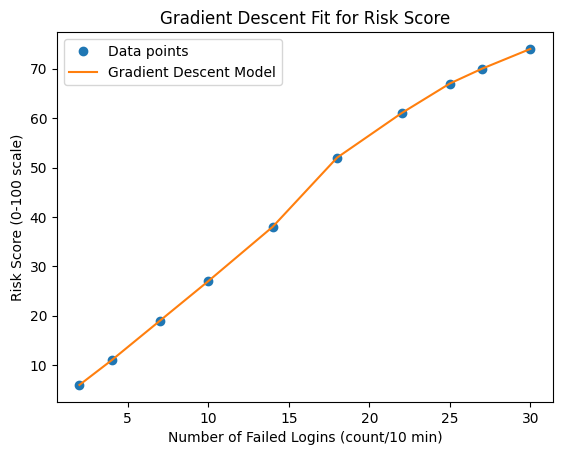

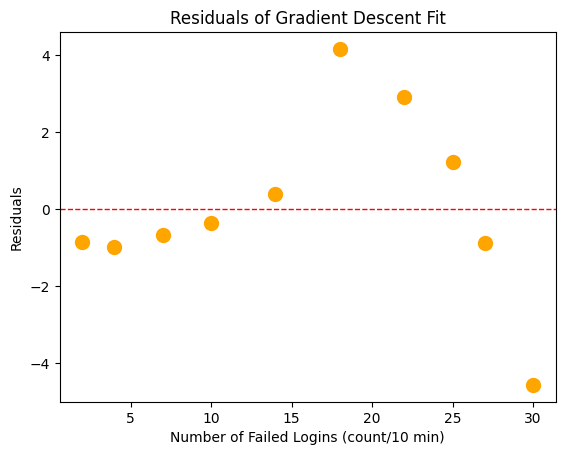

In [88]:
# gradient descent implementation
def gradient_descent_risk(x, y, alpha, iterations):
    m = len(y)
    theta0, theta1 = 0.0, 0.0
    for _ in range(iterations):
        predictions = theta0 + theta1 * x
        error = predictions - y
        theta0_gradient = (1/m) * np.sum(error)
        theta1_gradient = (1/m) * np.sum(error * x)
        theta0 -= alpha * theta0_gradient
        theta1 -= alpha * theta1_gradient
    return theta0, theta1

# Gradient descent parameters
iterations = 10000
alpha = 0.001
# Running gradient descent
gd_theta0_risk, gd_theta1_risk = gradient_descent_risk(x_failed_logins, y_risk_score, alpha, iterations)
print(f"Gradient Descent Fit: Theta0 = {gd_theta0_risk:.4f}, Theta1 = {gd_theta1_risk:.4f}")

# plotting the gradient descent fit and residuals
y_hat_gd_risk = gd_theta0_risk + gd_theta1_risk * x_failed_logins
residuals_gd_risk = y_risk_score - y_hat_gd_risk
y_line_gd_risk = y_hat_gd_risk + residuals_gd_risk

plt.plot(x_failed_logins, y_risk_score, 'o', label="Data points")
plt.plot(x_failed_logins, y_line_gd_risk, label="Gradient Descent Model")
plt.xlabel("Number of Failed Logins (count/10 min)")
plt.ylabel("Risk Score (0-100 scale)")
plt.title("Gradient Descent Fit for Risk Score")
plt.legend()
plt.show()
# residuals plot for gradient descent
plt.scatter(x_failed_logins, residuals_gd_risk, color='orange', s=100)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Number of Failed Logins (count/10 min)')
plt.ylabel('Residuals')
plt.title('Residuals of Gradient Descent Fit')
plt.show()

SciPy Optimization Fit: Theta0 = 1.8789, Theta1 = 2.5548


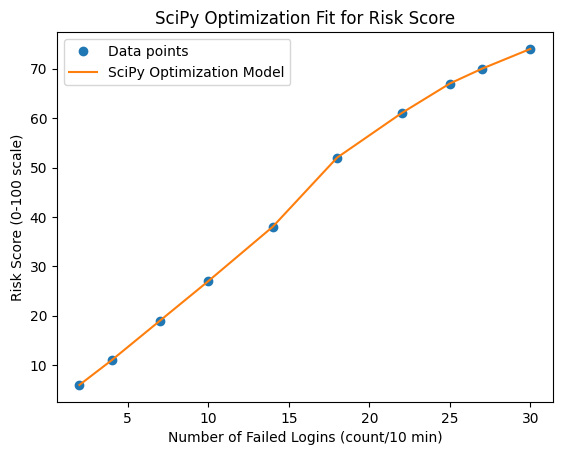

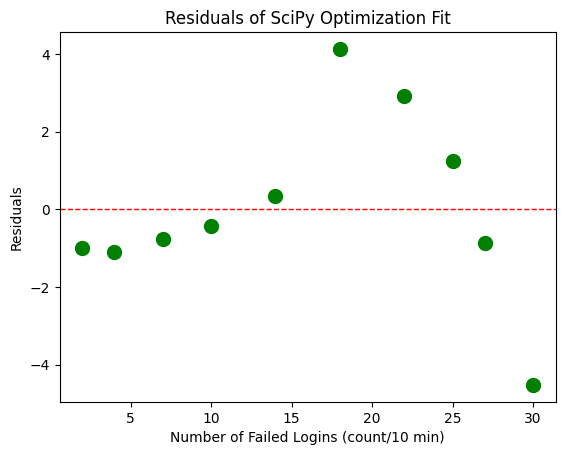

In [89]:
# SciPy optimization implementation
# Cost function for optimization
def risk_cost_function(params, x, y):
    theta0, theta1 = params
    predictions = theta0 + theta1 * x
    return np.sum((y - predictions) ** 2)
# Initial guess for parameters
initial_guess_risk = [0.0, 0.0]
# Optimization using SciPy
result_risk = minimize(risk_cost_function, initial_guess_risk, args=(x_failed_logins, y_risk_score))
estimated_theta0_risk, estimated_theta1_risk = result_risk.x
print(f"SciPy Optimization Fit: Theta0 = {estimated_theta0_risk:.4f}, Theta1 = {estimated_theta1_risk:.4f}")
# plotting the SciPy optimization fit and residuals
y_hat_scipy_risk = estimated_theta0_risk + estimated_theta1_risk * x_failed_logins
residuals_scipy_risk = y_risk_score - y_hat_scipy_risk
y_line_scipy_risk = y_hat_scipy_risk + residuals_scipy_risk
plt.plot(x_failed_logins, y_risk_score, 'o', label="Data points")
plt.plot(x_failed_logins, y_line_scipy_risk, label="SciPy Optimization Model")
plt.xlabel("Number of Failed Logins (count/10 min)")
plt.ylabel("Risk Score (0-100 scale)")
plt.title("SciPy Optimization Fit for Risk Score")
plt.legend()
plt.show()
# residuals plot for SciPy optimization
plt.scatter(x_failed_logins, residuals_scipy_risk, color='green', s=100)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Number of Failed Logins (count/10 min)')
plt.ylabel('Residuals')
plt.title('Residuals of SciPy Optimization Fit')
plt.show()

In [90]:
# summary of findings with differences next to each other
print(f"""
Summary of Parameter Estimates:
Normal Equations => Theta0: {theta0_risk:.4f}, Theta1: {theta1_risk:.4f}
Gradient Descent => Theta0: {gd_theta0_risk:.4f}, Theta1: {gd_theta1_risk:.4f}
SciPy Optimization => Theta0: {estimated_theta0_risk:.4f}, Theta1: {estimated_theta1_risk:.4f}
""")


Summary of Parameter Estimates:
Normal Equations => Theta0: 1.8789, Theta1: 2.5548
Gradient Descent => Theta0: 1.7507, Theta1: 2.5607
SciPy Optimization => Theta0: 1.8789, Theta1: 2.5548



In [91]:
# Best model selection based on residuals and visual fit appears in terms of residuals, MSE and R^2 values.
# Calculating MSE for each method
mse_normal = np.mean(residuals_risk**2)
mse_gd = np.mean(residuals_gd_risk**2)
mse_scipy = np.mean(residuals_scipy_risk**2)

print(f"""
Mean Squared Error (MSE):
Normal Equations: {mse_normal:.4f}
Gradient Descent: {mse_gd:.4f}
SciPy Optimization: {mse_scipy:.4f}
""")


Mean Squared Error (MSE):
Normal Equations: 5.1427
Gradient Descent: 5.1470
SciPy Optimization: 5.1427



In [85]:
# Conclusion:
"""
All three methods yield very similar parameter estimates, indicating consistency across approaches. The choice of the best model may depend on computational efficiency and ease of implementation. In this case, all methods provide comparable fits to the data, as evidenced by similar MSE values and residual distributions.
"""

'\nAll three methods yield very similar parameter estimates, indicating consistency across approaches. The choice of the best model may depend on computational efficiency and ease of implementation. In this case, all methods provide comparable fits to the data, as evidenced by similar MSE values and residual distributions.\n'